### 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

os.chdir("../")
from scripts import utils
from pathlib import Path
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

from mlxtend.evaluate import feature_importance_permutation
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.utils.estimator_checks import check_estimator
from mlxtend.feature_selection import (
    SequentialFeatureSelector,
)
from sklearn.model_selection import cross_val_predict, train_test_split
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
import matplotlib.ticker as ticker
import distclassipy as dcpy

epsilon = np.finfo(np.float32).eps

with open("settings.txt") as f:
    settings_dict = json.load(f)
seed_val = settings_dict["seed_choice"]
np.random.seed(seed_val)
sns_dict = settings_dict["sns_dict"]
sns.set_theme(**sns_dict)

unique_metrics = ['euclidean',
 'braycurtis',
 'canberra',
 'cityblock',
 'chebyshev',
 'clark',
 'correlation',
 'cosine',
 'hellinger',
 'jaccard',
 'lorentzian',
 # 'marylandbridge',
 'meehl',
 'motyka',
 'soergel',
 'wave_hedges',
 'kulczynski',
 # 'add_chisq'
                 ]

In [2]:
features = pd.read_parquet("data/reduced_balancedfeatures_LATEST.parquet")
features["class"].value_counts()

final_features = features.drop(["Timespan", "Coordinate_x", "Coordinate_y", "Coordinate_z", "class"], axis=1).columns

features = features.sample(frac=1)

y_normal_df = features["class"]
# X_df = features.drop(["Coordinate_x", "Coordinate_y", "Coordinate_z", "class"], axis=1)
X_normal_df = features.loc[:, final_features]

other_features_df = pd.read_parquet("data/otherclassobjs_features.parquet")
other_features_df.index.name = "snid"
other_lc_df = pd.read_parquet("data/otherclassobjs.parquet")
other_lc_df.index.name = "snid"

other_lc_df=other_lc_df[~other_lc_df["class"].isin(['d-Sct', 'Cepheid', 'EB', 'RRL'])]
other_features_df=other_features_df.loc[other_lc_df.index]


other_lc_df = other_lc_df.loc[other_features_df.index]

assert (other_lc_df.index == other_features_df.index).all()

X_anom_df = other_features_df.loc[:, X_normal_df.columns].dropna()
X_anom_df = X_anom_df.drop(np.intersect1d(X_anom_df.index, X_normal_df.index))
y_anom_df = other_lc_df.loc[X_anom_df.index]["class"]
X_anom_df=X_anom_df.loc[y_anom_df.index]

X_df = pd.concat([X_normal_df, X_anom_df])
y_df = pd.concat([y_normal_df, y_anom_df])

In [3]:
assert (X_df.index == y_df.index).all()

### 1. Isolation Forest

In [4]:
from sklearn.ensemble import IsolationForest
from scipy import stats

In [5]:
def runif(random_state, X_traindf, X_testdf):
    clf = IsolationForest(
        max_samples=10, contamination="auto", random_state=random_state
    )
    clf.fit(X_traindf)  # , sample_weight=1.0/(Xfixed[:,2,:])**2)
    scores_pred_Norm = clf.decision_function(X_testdf)
    # scores_pred_Norm = clf.score_samples(X)
    # .sample_score(X)

    threshold_Norm = stats.scoreatpercentile(scores_pred_Norm, 100 * 0.1)
    #y_predNorm = clf.predict(X)
    abornmality = -scores_pred_Norm
    iforest_df = pd.DataFrame(
        abornmality, columns=["abnormality"], index=X_testdf.index,
    )  # higher is more abnormal
    # iforest_df.index.name = "sample_num"
    # iforest_df = iforest_df.sort_values(by="abnormality", ascending=False)
    return iforest_df.index, iforest_df

In [6]:
ranksIF = []
ranksIDdfs = []
ifseeds = np.random.randint(100, 1000, 3)
for i in ifseeds:
    _ = runif(i, X_traindf=X_normal_df, X_testdf=X_df)
    ranksIF.append(_[0])
    ranksIDdfs.append(_[1])
ranksIF

[Index([ 93852051, 133953454, 156704754,  94869465, 143158599,  97209193,
        118286557, 145870285, 107197896,  34324163,
        ...
         35100352,  92637767, 103949738,  98960985, 134905649,  26660263,
         85155628, 135470168,  69018019, 130127663],
       dtype='int64', name='snid', length=3351),
 Index([ 93852051, 133953454, 156704754,  94869465, 143158599,  97209193,
        118286557, 145870285, 107197896,  34324163,
        ...
         35100352,  92637767, 103949738,  98960985, 134905649,  26660263,
         85155628, 135470168,  69018019, 130127663],
       dtype='int64', name='snid', length=3351),
 Index([ 93852051, 133953454, 156704754,  94869465, 143158599,  97209193,
        118286557, 145870285, 107197896,  34324163,
        ...
         35100352,  92637767, 103949738,  98960985, 134905649,  26660263,
         85155628, 135470168,  69018019, 130127663],
       dtype='int64', name='snid', length=3351)]

In [7]:
df=pd.concat(ranksIDdfs,axis=1)
df.columns = ["if1", "if2", "if3"]
# df = df.sort_values(by="if2",ascending=False)
df

,if1,if2,if3
snid,,,
93852051,-0.011517,-0.018857,-0.020074
133953454,-0.011615,-0.016906,-0.014562
156704754,-0.020486,-0.015392,-0.030329
94869465,-0.039581,-0.041673,-0.032620
143158599,-0.032341,-0.007743,-0.010724
...,...,...,...
26660263,0.075819,0.060976,0.060875
85155628,0.087645,0.098906,0.080394
135470168,0.069555,0.058834,0.072313


In [8]:
assert (df.index==y_df.index).all()

In [9]:
df["class"] = y_df.loc[df.index]

In [10]:
df.sort_values("if2",ascending=False).iloc[:20]

,if1,if2,if3,class
snid,,,,
103949738,0.129322,0.119241,0.094712,dwarf-nova
135511375,0.066525,0.108297,0.060258,CEP
131043464,0.076288,0.103284,0.090264,dwarf-nova
9588339,0.072786,0.102634,0.082868,CEP
58020436,0.080121,0.099882,0.063870,EB
85155628,0.087645,0.098906,0.080394,dwarf-nova
132288802,0.068036,0.094949,0.084737,uLens-Single-GenLens
151011490,0.106965,0.092851,0.076215,uLens-Single-GenLens
4090466,0.079047,0.092689,0.083762,CEP


### Distances

In [11]:
smallfeatures = [
    "SPM_A_Y",
    "Multiband_period",
    "r-i",
    "Harmonics_phase_4_i",
    "Harmonics_phase_2_r",
    "Power_rate_4",
]

In [12]:
lcdc = dcpy.DistanceMetricClassifier(
    scale=True,
    central_stat="median",
    dispersion_stat="std",
)
lcdc.fit(X_normal_df.loc[:,smallfeatures], y_normal_df)

DistanceMetricClassifier()

In [13]:
dist_df_dict = {}
for metric in tqdm(unique_metrics, desc="Metric", leave=True):
    metric_str = utils.get_metric_name(metric)
    _ = lcdc.predict_and_analyse(X_df.loc[:,smallfeatures], metric=metric)

    dist_df = lcdc.centroid_dist_df_

    dist_df["minimum_distance"] = dist_df.min(axis=1)

    dist_df_dict[metric_str] = dist_df

Metric:   0%|          | 0/16 [00:00<?, ?it/s]

In [14]:
n_metrics = len(unique_metrics)
clusters = np.unique(y_normal_df)
n_clusters = len(clusters)
n_objects = dist_df.shape[0]


print(f"n: {n_objects=}")
print(f"m: {n_metrics=}")
print(f"k: {n_clusters=}")

n: n_objects=3351
m: n_metrics=16
k: n_clusters=4


In [15]:
dist_df_arr = np.zeros((n_objects, n_clusters, n_metrics))
for i in range(n_objects):
    for j, cluster in enumerate(clusters):
        for k, metric in enumerate(unique_metrics):
            metric_str = utils.get_metric_name(metric)
            dist_df_arr[i, j, k] = dist_df_dict[metric_str].loc[i, f"{cluster}_dist"]

In [16]:
cluster_aggregates = ["min"]
metric_aggregates = ["median"]

In [17]:
dist_aggregates = np.zeros((len(dist_df_dict["Euclidean"]), 3, 2))
dist_aggregates.shape

(3351, 3, 2)

In [18]:
dist_minK_by_M = np.array([dist_df_dict[utils.get_metric_name(metric)]["minimum_distance"]
                           for i,metric in enumerate(unique_metrics)])

In [19]:
assert (ranksIDdfs[0].index == X_df.index).all()

## THIS IS THE REASON WHY I REMOVED SORTING FROM IF FUNCTION

In [20]:
dist_aggregates = pd.DataFrame(np.concatenate(
    [np.percentile(dist_minK_by_M, [0.5], axis=0), #metric percentiles on the min of clusters
    ]).T,
                               columns=[k+m for k in ["min"] for m in ["med"]],
                              index=X_df.index)

dist_aggregates = pd.concat([dist_aggregates,df],axis=1)
dist_aggregates

,minmed,if1,if2,if3,class
snid,,,,,
93852051,0.018085,-0.011517,-0.018857,-0.020074,EB
133953454,0.010920,-0.011615,-0.016906,-0.014562,DSCT
156704754,0.009763,-0.020486,-0.015392,-0.030329,DSCT
94869465,0.028574,-0.039581,-0.041673,-0.032620,DSCT
143158599,0.017767,-0.032341,-0.007743,-0.010724,EB
...,...,...,...,...,...
26660263,0.138290,0.075819,0.060976,0.060875,dwarf-nova
85155628,0.184497,0.087645,0.098906,0.080394,dwarf-nova
135470168,0.111457,0.069555,0.058834,0.072313,dwarf-nova


In [21]:
assert (dist_aggregates.index == X_df.index).all()

In [22]:
df = dist_aggregates

In [23]:
assert (df.index == X_df.index).all()

In [24]:
normal_classes = ["CEP", "DSCT", "EB", "RRL"]
df['status'] = df['class'].apply(lambda x: 'normal' if x in normal_classes else 'anomalous')

In [25]:
df.sort_values("if2",ascending=False).iloc[:50]

,minmed,if1,if2,if3,class,status
snid,,,,,,
103949738,0.213769,0.129322,0.119241,0.094712,dwarf-nova,anomalous
135511375,0.017744,0.066525,0.108297,0.060258,CEP,normal
131043464,0.329001,0.076288,0.103284,0.090264,dwarf-nova,anomalous
9588339,0.311006,0.072786,0.102634,0.082868,CEP,normal
58020436,0.035979,0.080121,0.099882,0.063870,EB,normal
85155628,0.184497,0.087645,0.098906,0.080394,dwarf-nova,anomalous
132288802,0.634400,0.068036,0.094949,0.084737,uLens-Single-GenLens,anomalous
151011490,0.137168,0.106965,0.092851,0.076215,uLens-Single-GenLens,anomalous
4090466,0.258513,0.079047,0.092689,0.083762,CEP,normal


In [26]:
df.sort_values("minmed",ascending=False).iloc[:50]

,minmed,if1,if2,if3,class,status
snid,,,,,,
141445943,0.708867,0.046672,0.003661,0.049923,ILOT,anomalous
118315745,0.696301,0.077567,0.042666,0.053875,uLens-Single-GenLens,anomalous
103313063,0.683778,0.066559,0.049699,0.072683,SNIa-91bg,anomalous
76558149,0.639578,0.065297,0.051835,0.063353,SNIc-Templates,anomalous
58287001,0.639550,0.075688,0.061764,0.078948,SNIIn-MOSFIT,anomalous
132288802,0.634400,0.068036,0.094949,0.084737,uLens-Single-GenLens,anomalous
91170406,0.632973,0.042810,0.005330,0.050384,PISN-STELLA_HECORE,anomalous
40754187,0.624652,0.122208,0.087170,0.101873,uLens-Binary,anomalous
92717442,0.621094,0.027401,-0.007025,0.024929,CEP,normal


NameError: name 'enumearate' is not defined

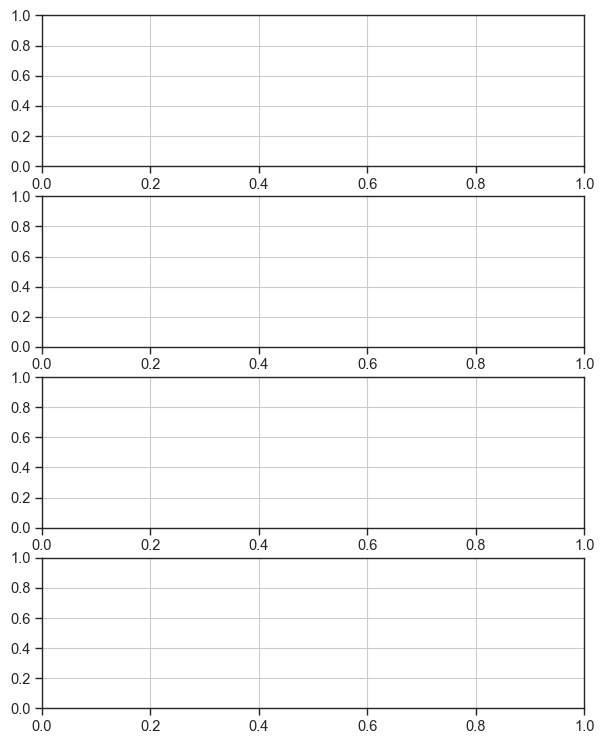

In [27]:
all_methods=["minmed", "if1", "if2", "if3"]
fig, axs = plt.subplots(len(all_methods),1, figsize=(7,7*len(all_methods)//3))
axs = axs.ravel()
for i, method in enumearate(all_methods):
    sns.histplot(data=df, x=method, hue='status', multiple="dodge", shrink=0.8, ax=axs[i],bins=20)
    axs[i].set_yscale("log")
plt.tight_layout()
plt.show()